# Credit Card Fraud Detection

This is the second of two capstones I built after finishing Andrew Ng's Machine Learning Specialization. The first one (forest cover type) was a roughly balanced multiclass problem and let me practise everything from logistic regression up to gradient-boosted trees. The point of this one is the opposite: a binary problem with an extreme class imbalance, where most of the work is figuring out the right metrics and the right threshold instead of the right model.

Dataset: the well-known ULB credit-card fraud set — 284,807 transactions over two days in September 2013, of which 492 (~0.17%) are fraudulent. Most features (V1..V28) are anonymised PCA components produced by the original authors; only `Amount` is raw. I pull it from OpenML so the download doesn't need a Kaggle account.

## 1. Setup and load

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"positives — train {y_train.sum()}, val {y_val.sum()}, test {y_test.sum()}")

train (182276, 29) | val (45569, 29) | test (56962, 29)
positives — train 315, val 79, test 98


## 2. A look at the data

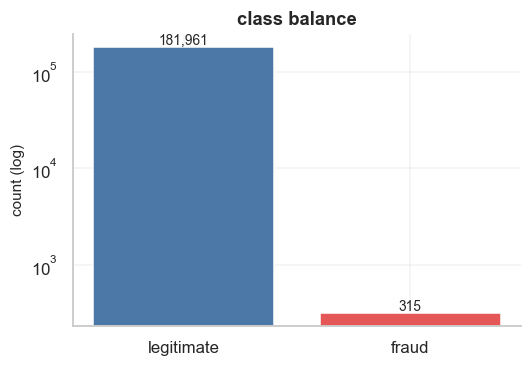

In [2]:
plots.class_balance(y_train)
plt.tight_layout()
plt.show()

About 1 fraud per 580 legitimate transactions. Accuracy is useless here — predicting *legit* every time would already score 99.83%. I'll lean on precision, recall, F1, and the precision-recall curve instead.

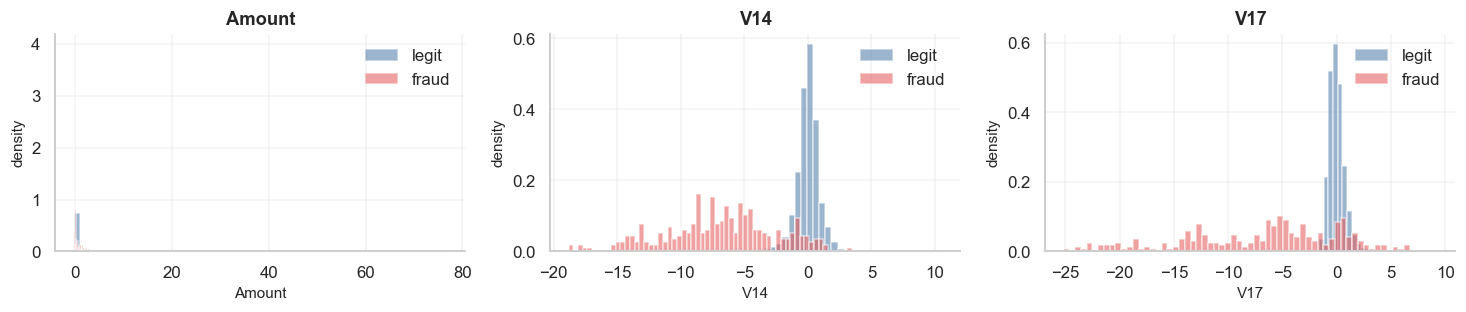

In [3]:
# strongest single-feature separators in this set
df = pd.DataFrame(np.c_[X_train, y_train], columns=data.FEATURE_NAMES + ["y"])
plots.feature_distributions(df, ["Amount", "V14", "V17"])
plt.tight_layout()
plt.show()

Fraud transactions sit in noticeably different regions of V14 and V17 — those two are the strongest single-feature separators in this set. `Amount` is scaled in `data.load` so the from-scratch logistic regression doesn't blow up on the raw values.

## 3. Logistic regression from scratch (with class weights)

Plain mini-batch SGD, L2 regularisation, and a per-sample weight that's inversely proportional to class frequency — without it the gradient is dominated by the legitimate transactions and the model basically learns to always predict 0.

In [4]:
from sklearn.metrics import average_precision_score

clf_scratch = models.LogisticRegressionWeighted(
    lr=0.05, l2=1e-4, epochs=15, batch=512, seed=0,
).fit(X_train, y_train, X_val, y_val)

scores_scratch = clf_scratch.predict_proba(X_val)
print(f"AP on val: {average_precision_score(y_val, scores_scratch):.3f}")

AP on val: 0.808


## 4. Logistic regression with sklearn

In [5]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(
    class_weight="balanced", max_iter=1000, solver="lbfgs", n_jobs=-1,
).fit(X_train, y_train)

scores_sk = clf_sk.predict_proba(X_val)[:, 1]
print(f"AP on val: {average_precision_score(y_val, scores_sk):.3f}")

AP on val: 0.817


## 5. Small NN in Keras

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
class_weight = {0: len(y_train) / (2 * n_neg), 1: len(y_train) / (2 * n_pos)}

nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
nn.fit(X_train, y_train, validation_data=(X_val, y_val),
       epochs=10, batch_size=512, class_weight=class_weight, verbose=0)

scores_nn = nn.predict(X_val, verbose=0).ravel()
print(f"AP on val: {average_precision_score(y_val, scores_nn):.3f}")

AP on val: 0.789


## 6. Histogram gradient boosting

sklearn's `HistGradientBoostingClassifier` handles the imbalance via `class_weight='balanced'`. Fast, and a strong baseline on tabular data.

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200, class_weight="balanced", random_state=0,
).fit(X_train, y_train)

scores_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"AP on val: {average_precision_score(y_val, scores_hgb):.3f}")

AP on val: 0.799


## 7. Threshold tuning

All four models above output scores; turning those into 0/1 decisions needs a threshold. The "right" threshold depends on the cost of a missed fraud vs a false alarm. Here I'll just maximise F1 on the validation set and take that as a sensible operating point.

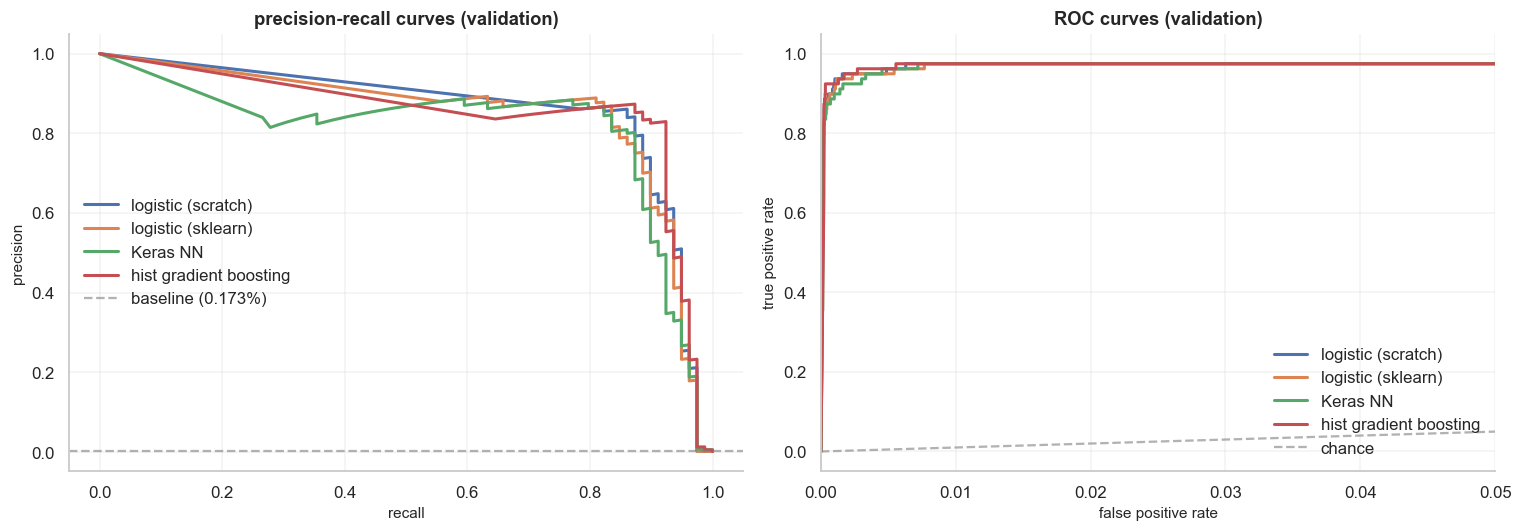

In [8]:
val_scores = {
    "logistic (scratch)": scores_scratch,
    "logistic (sklearn)": scores_sk,
    "Keras NN": scores_nn,
    "hist gradient boosting": scores_hgb,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plots.pr_curves(y_val, val_scores, ax=axes[0])
plots.roc_curves(y_val, val_scores, ax=axes[1])
plt.tight_layout()
plt.show()

All four supervised models cluster on the PR plot — at this scale the differences are small. The ROC plot is zoomed to the low-FPR region because anything past a few percent FPR floods the operations team with false alarms; that's where the model actually has to behave.

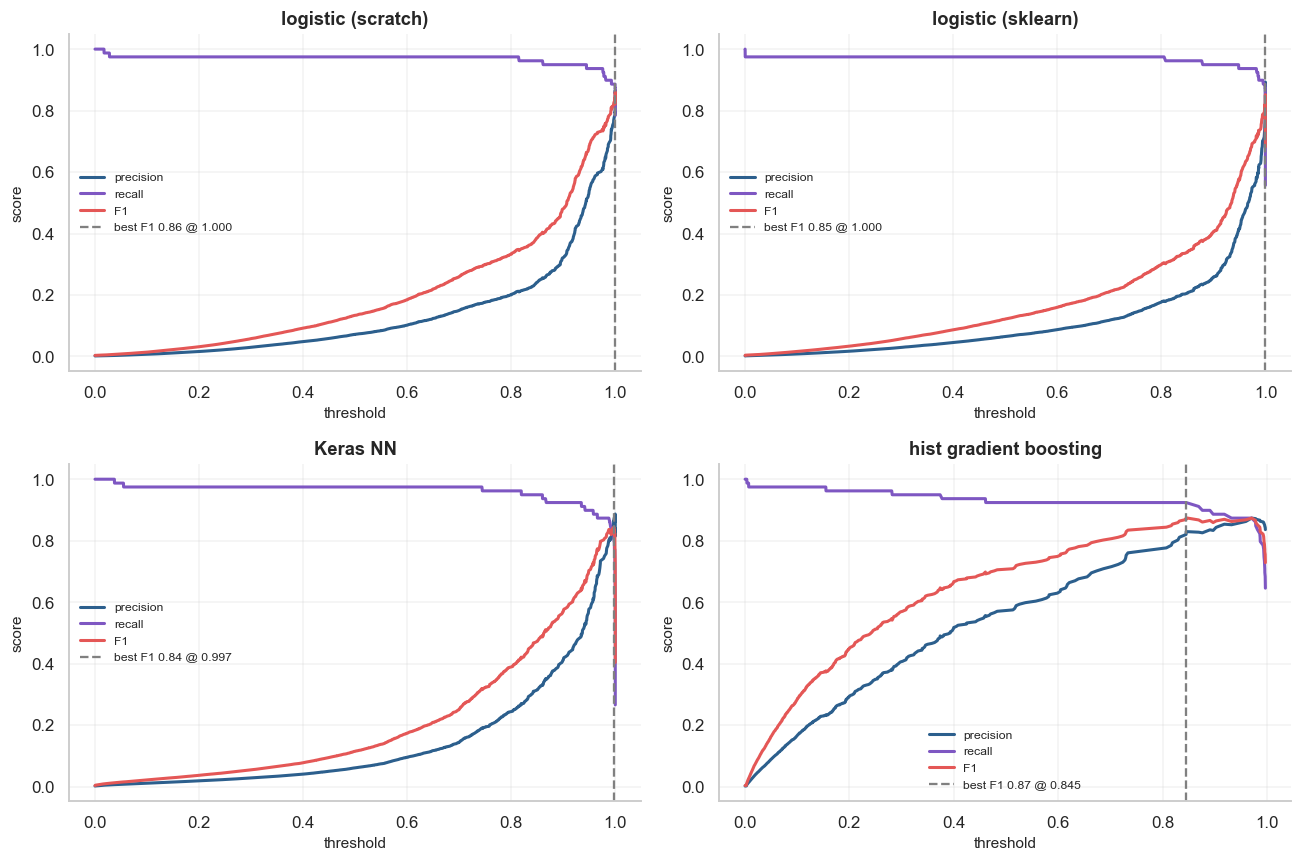

chosen thresholds:
  logistic (scratch)        1.000
  logistic (sklearn)        1.000
  Keras NN                  0.997
  hist gradient boosting    0.845


In [9]:
thresholds = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, s) in zip(axes.flat, val_scores.items()):
    _, t = plots.f1_vs_threshold(y_val, s, name, ax=ax)
    thresholds[name] = float(t)
plt.tight_layout()
plt.show()
print("chosen thresholds:")
for k, v in thresholds.items():
    print(f"  {k:25s} {v:.3f}")

Each panel shows precision, recall, and F1 as a function of the decision threshold for one model. The dashed line is the threshold that maximises F1 on the validation set — the precision/recall tradeoff there is what gets reported below.

## 8. Score distributions

Histograms of model output for fraud vs legit transactions. A well-behaved model should put fraud and legit into clearly different score bands. Anywhere they overlap is where false positives and false negatives live.

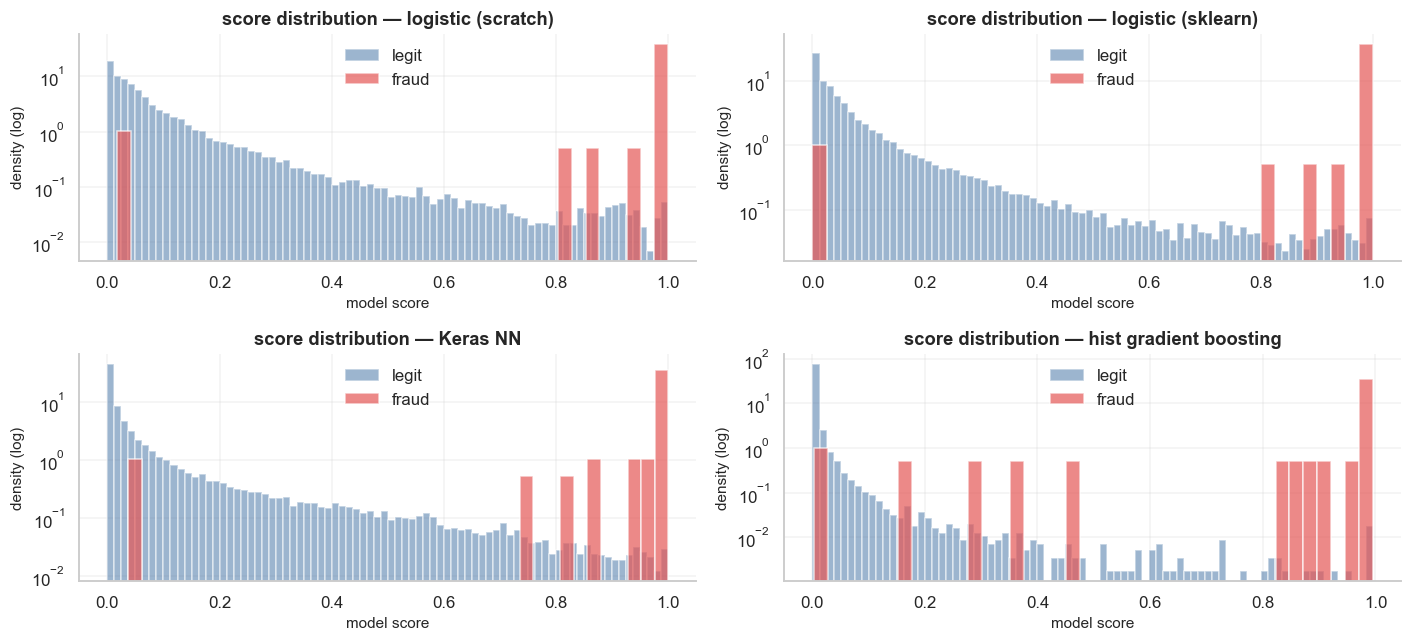

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, (name, s) in zip(axes.flat, val_scores.items()):
    plots.score_distributions(y_val, s, name, ax=ax)
plt.tight_layout()
plt.show()

## 9. Gaussian anomaly detection from scratch

The unsupervised baseline from Part III: fit a Gaussian per feature on the *legitimate* transactions only, score every transaction by its log-density, and flag the lowest-density ones. Threshold (epsilon) is picked on the validation set by maximising F1, exactly the procedure in the lectures.

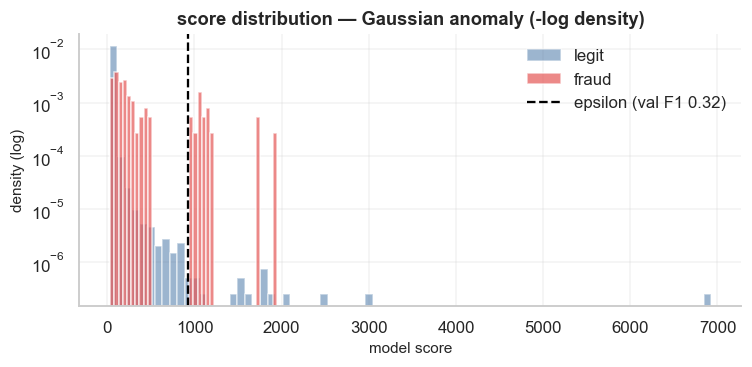

chosen epsilon: -927.49, val F1: 0.319


In [11]:
anom = models.GaussianAnomalyDetector().fit(X_train[y_train == 0])
val_anom = anom.score(X_val)
eps, val_f1 = anom.select_epsilon(val_anom, y_val)

fig, ax = plt.subplots(figsize=(7, 3.5))
plots.score_distributions(y_val, -val_anom, "Gaussian anomaly (-log density)", ax=ax)
ax.axvline(-eps, color="black", linestyle="--", label=f"epsilon (val F1 {val_f1:.2f})")
ax.legend()
plt.tight_layout()
plt.show()
print(f"chosen epsilon: {eps:.2f}, val F1: {val_f1:.3f}")

F1 here is much lower than the supervised models — expected, because anomaly detection sees no fraud labels at training time. It's still useful as a sanity check: anything the Gaussian model flags is genuinely far from the bulk of legitimate behaviour.

## 10. Final comparison on the test set

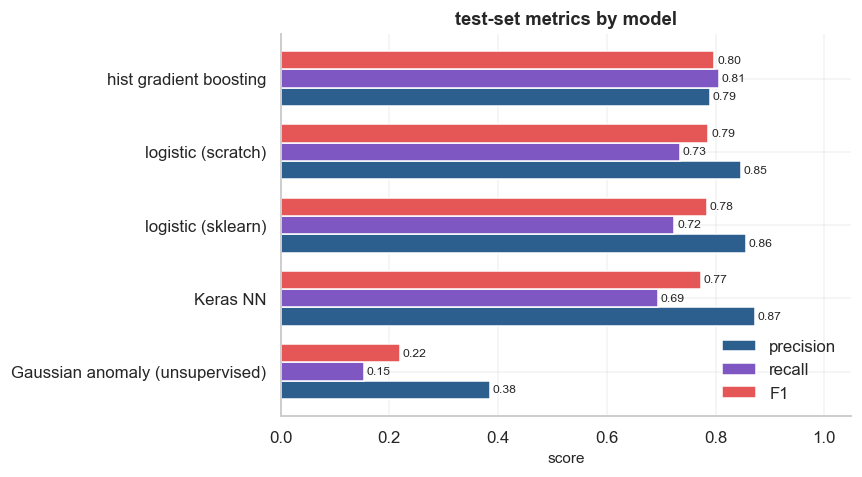

,model,precision,recall,F1,PR-AUC
0,hist gradient boosting,0.790,0.806,0.798,0.719
1,logistic (scratch),0.847,0.735,0.787,0.716
2,logistic (sklearn),0.855,0.724,0.785,0.697
3,Keras NN,0.872,0.694,0.773,0.672
4,Gaussian anomaly (unsupervised),0.385,0.153,0.219,0.135


In [12]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
)

test_scores = {
    "logistic (scratch)": clf_scratch.predict_proba(X_test),
    "logistic (sklearn)": clf_sk.predict_proba(X_test)[:, 1],
    "Keras NN": nn.predict(X_test, verbose=0).ravel(),
    "hist gradient boosting": hgb.predict_proba(X_test)[:, 1],
}

results = []
for name, s in test_scores.items():
    pred = (s >= thresholds[name]).astype(int)
    results.append({
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "PR-AUC": average_precision_score(y_test, s),
    })

# anomaly detector uses inverted scoring
test_anom = anom.score(X_test)
pred_anom = (test_anom < eps).astype(int)
results.append({
    "model": "Gaussian anomaly (unsupervised)",
    "precision": precision_score(y_test, pred_anom),
    "recall": recall_score(y_test, pred_anom),
    "F1": f1_score(y_test, pred_anom),
    "PR-AUC": average_precision_score(y_test, -test_anom),
})

results_df = pd.DataFrame(results)
plots.model_comparison(results_df)
plt.tight_layout()
plt.show()
results_df.round(3).sort_values("F1", ascending=False).reset_index(drop=True)

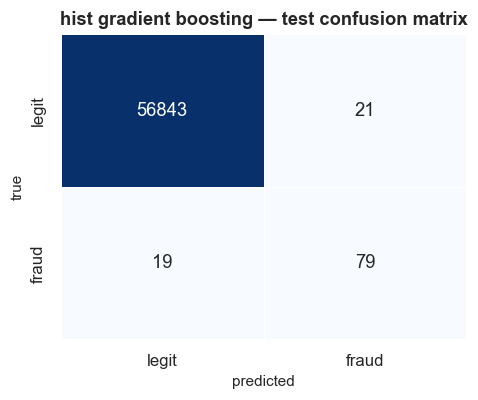

best F1: 0.798 (hist gradient boosting)


In [13]:
# best model — confusion matrix on test
best_row = results_df.loc[results_df["F1"].idxmax()]
best_name = best_row["model"]
best_scores = test_scores[best_name]
best_pred = (best_scores >= thresholds[best_name]).astype(int)

fig, ax = plt.subplots(figsize=(4.5, 3.8))
plots.confusion(y_test, best_pred, f"{best_name} — test confusion matrix", ax=ax)
plt.tight_layout()
plt.show()
print(f"best F1: {best_row['F1']:.3f} ({best_name})")

The supervised models all reach F1 in roughly the same range; the anomaly detector lags behind, which it should given how much less it knows. The big practical lesson — which matches the course — is that on a problem this skewed, picking the threshold matters as much as picking the model.